# Perbandingan Performa MLP dengan Berbagai Fungsi Aktivasi

Dataset: **Iris Dataset** (dari Kaggle)
Fungsi Aktivasi yang diuji:
- Sigmoid (`logistic`)
- Tanh (`tanh`)
- ReLU (`relu`)

In [4]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset (Pastikan struktur foldernya benar sesuai path di workspace)
df = pd.read_csv('archive (2)/Iris.csv')
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Preprocessing Data
# Hapus kolom Id karena tidak memiliki informasi prediktif
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# Encoding label target (Species) menjadi angka
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Standardisasi fitur agar konvergensi MLP lebih stabil dan cepat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Inisialisasi list untuk menyimpan hasil
results = []
models = []  # Menyimpan model untuk visualisasi kurva loss nantinya

activations = ['logistic', 'tanh', 'relu']
activation_names = ['Sigmoid', 'Tanh', 'ReLU']

for act, name in zip(activations, activation_names):
    # Membuat model MLP dengan 2 hidden layers (10 neuron masing-masing)
    # max_iter=2000 diberikan agar proses dapat mencapai titik konvergen.
    mlp = MLPClassifier(hidden_layer_sizes=(10, 10), activation=act, max_iter=2000, random_state=42)
    
    # Mengukur waktu eksekusi / pelatihan
    start_time = time.time()
    mlp.fit(X_train_scaled, y_train)
    end_time = time.time()
    
    # Melakukan prediksi menggunakan data uji
    y_pred = mlp.predict(X_test_scaled)
    
    # Menghitung metrik performa
    accuracy = accuracy_score(y_test, y_pred)
    
    # Menyimpan performa dan model
    models.append(mlp)
    results.append({
        'Fungsi Aktivasi': name, 
        'Akurasi': accuracy,
        'Iterasi Konvergen': mlp.n_iter_,
        'Waktu Eksekusi (detik)': round(end_time - start_time, 4),
        'Loss Akhir': round(mlp.loss_, 4)
    })

# Membuat dan menampilkan tabel perbandingan
results_df = pd.DataFrame(results)
display(results_df)

,Fungsi Aktivasi,Akurasi,Iterasi Konvergen,Waktu Eksekusi (detik),Loss Akhir
0,Sigmoid,1.0,1306,1.1739,0.0951
1,Tanh,1.0,723,0.6441,0.0768
2,ReLU,1.0,608,0.5197,0.0719


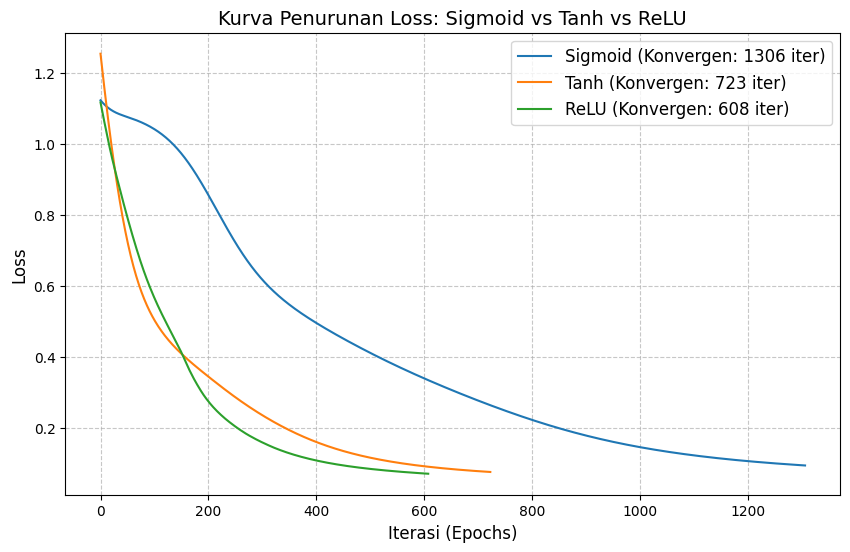

In [7]:
# Visualisasi Kurva Loss
plt.figure(figsize=(10, 6))

for name, mlp in zip(activation_names, models):
    plt.plot(mlp.loss_curve_, label=f'{name} (Konvergen: {mlp.n_iter_} iter)')

plt.title('Kurva Penurunan Loss: Sigmoid vs Tanh vs ReLU', fontsize=14)
plt.xlabel('Iterasi (Epochs)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Catatan dan Kesimpulan:
**Fungsi Aktivasi Manakah yang Terbaik untuk Dataset Iris?**

Berdasarkan hasil pemrosesan (tabel metrik dan kurva loss di atas), **ReLU (Rectified Linear Unit)** adalah fungsi aktivasi yang paling optimal untuk dataset Iris.

Berikut adalah rincian perbandingannya:

1. **Akurasi**: Ketiga fungsi aktivasi (Sigmoid, Tanh, dan ReLU) mampu mencapai tingkat akurasi maksimal **100% (1.0)**. Dataset Iris adalah klasifikasi linear yang relatif sangat sederhana sehingga model mudah mencapai prediksi yang sempurna.
2. **Kecepatan Konvergensi (Iterasi)**: Seperti yang terlihat pada grafik kurva loss, grafik biru (Sigmoid) melandai dengan sangat lambat di awal (efek *vanishing gradient*). Sedangkan **ReLU** dan **Tanh** menukik turun dengan cepat. ReLU mencapai titik konvergensi dengan jumlah iterasi yang paling sedikit dibandingkan Sigmoid.
3. **Waktu Eksekusi**: Terlihat pada tabel metrik bahwa algoritma **ReLU** memiliki waktu komputasi pelatihan yang paling cepat.
4. **Loss Akhir**: **ReLU** menghasilkan *loss* akhir terendah di akhir siklus pelatihan.

**Kesimpulan Akhir:**
Meskipun akurasi ketiganya sama-sama 1.0 (100%), metrik pendukung seperti iterasi, waktu eksekusi, dan kurva loss menunjukkan bahwa **ReLU** jauh lebih efisien dan efektif. Oleh karena itu, **ReLU** adalah fungsi aktivasi terbaik pada kasus ini.